In [ ]:
%load_ext autoreload
%autoreload 2
from dataclasses import replace
from rankers.config import Config
from rankers.simulate import run, run_replicates, run_replicates_and_save_all_trajectories, run_beta_sweep
import numpy as np
import matplotlib.pyplot as plt
from rankers.viz import plot_trajectory_grid, plot_trajectory_heatmap_grid, plot_trajectory_heatmap_avg


# Shared base: fixed-magnitude symmetric pool, baseline updating,
# neighbor reception, grow-from-seed repertoire, window of 1.
base = Config(
    n=500,
    k=32,
    p_rewire=0.01,

    n_claims=200,
    claim_scheme="fixed",
    llr_mag=1.0,

    repertoire_seed_size=5,
    belief_std=0.5,

    history_window=1,
    n_surfaced=1,
    ranker="baseline",
    receiver="neighbors",

    biases=("baseline",),

    n_steps=20000,
    record_every=20,
    n_tracked=1,
    seed=404,
    emission_scheme="sign"
)


In [14]:
betas = np.logspace(0, 10, 3, base=2)
# add an element to betas: in position 0, insert 0.0
betas = np.insert(betas, 0, 0.0)
print(betas)

sweep = run_beta_sweep(base, betas, n_reps=60)

[0.000e+00 1.000e+00 3.200e+01 1.024e+03]
Running β = 0.0 ...
Running β = 1.0 ...
Running β = 32.0 ...
Running β = 1024.0 ...


In [ ]:
betas = np.array([0, 1, 8, 32, 256, 1024, 1024*4])
print(betas)

sweep = run_beta_sweep(base, betas, n_reps=100)

[   0    1    8   32  256 1024 4096]
Running β = 0 ...
Running β = 1 ...
Running β = 8 ...
Running β = 32 ...
Running β = 256 ...
Running β = 1024 ...
Running β = 4096 ...


In [21]:
betas3 = np.array([256, 300, 400])
print(betas3)

sweep3 = run_beta_sweep(base, betas3, n_reps=60)

[256 300 400]
Running β = 256 ...
Running β = 300 ...
Running β = 400 ...


In [26]:
# merge betas and betas2 into a single array, sorted
betas_all = np.sort(np.concatenate((betas, betas2, betas3)))
# merge sweep and sweep2 into a single dictionary, with keys from betas_all
sweep_all = {**sweep, **sweep2, **sweep3}

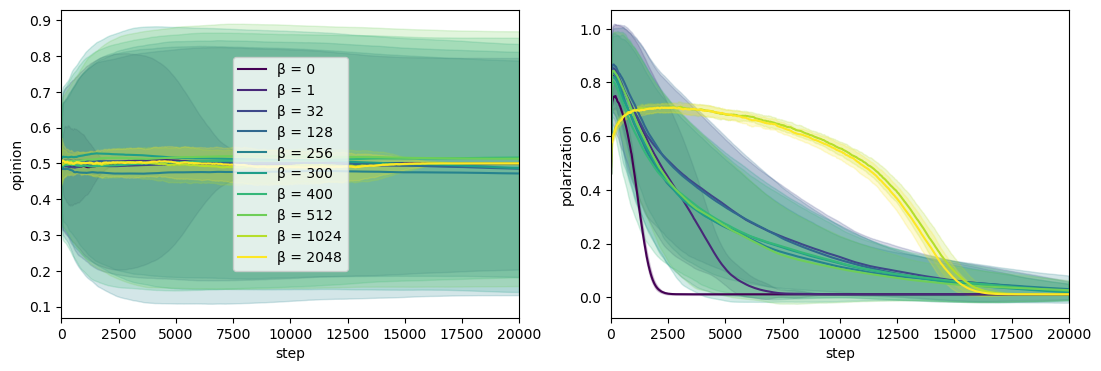

In [28]:
beta = list(sweep_all.keys())
aggs   = [sweep_all[b] for b in betas_all]
labels = [f"β = {b:g}" for b in betas_all]

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(13, 4))
plot_metric_comparison(aggs, "opinion", "polarization", ax_left, ax_right, labels=labels, x_lim=(0, 20000), record_every=20)

In [30]:
# save sweep_all to a file
import pickle

with open("results/Experiment_2/sweep_all.pkl", "wb") as f:
    pickle.dump(sweep_all, f)



In [7]:
# collapse steepness via max negative slope of polarization(t)
def max_negative_slope(sweep, betas, record_every):
    """Steepest descent of polarization for each beta. Returns dict beta -> slope (per step)."""
    slopes = {}
    for beta in betas:
        pol = sweep[beta]["mean"]["polarization"]        # (n_records,)
        d = np.diff(pol) / record_every
        slopes[beta] = d.min()
    return slopes

def plot_max_negative_slope(sweep, betas, record_every, ax=None):
    """Bar plot: steepest polarization descent vs beta."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))
    slopes = max_negative_slope(sweep, betas, record_every)
    ax.bar([str(b) for b in betas], [abs(slopes[b]) for b in betas])
    ax.set_xlabel("β")
    ax.set_ylabel("max |negative slope| of polarization")
    ax.set_title("Collapse steepness")
    return ax

Running β = 0.0 ...
Running β = 1.0 ...
Running β = 32.0 ...
Running β = 1024.0 ...


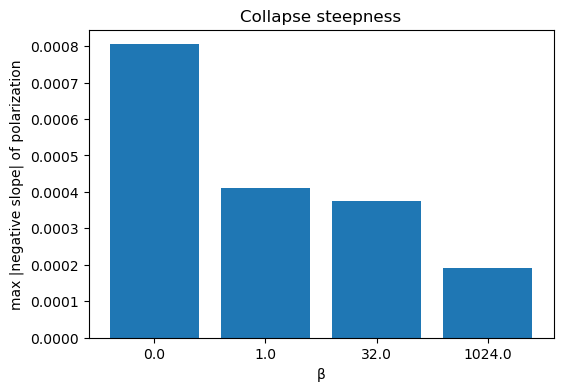

In [8]:
betas = [0.0, 1.0, 32.0, 1024.0]
sweep = run_beta_sweep(base, betas, n_reps=20)

fig, ax = plt.subplots(figsize=(6, 4))
plot_max_negative_slope(sweep, betas, record_every=base.record_every, ax=ax)
plt.show()

C:\Users\nel_t\AppData\Local\Temp\ipykernel_27644\808794739.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


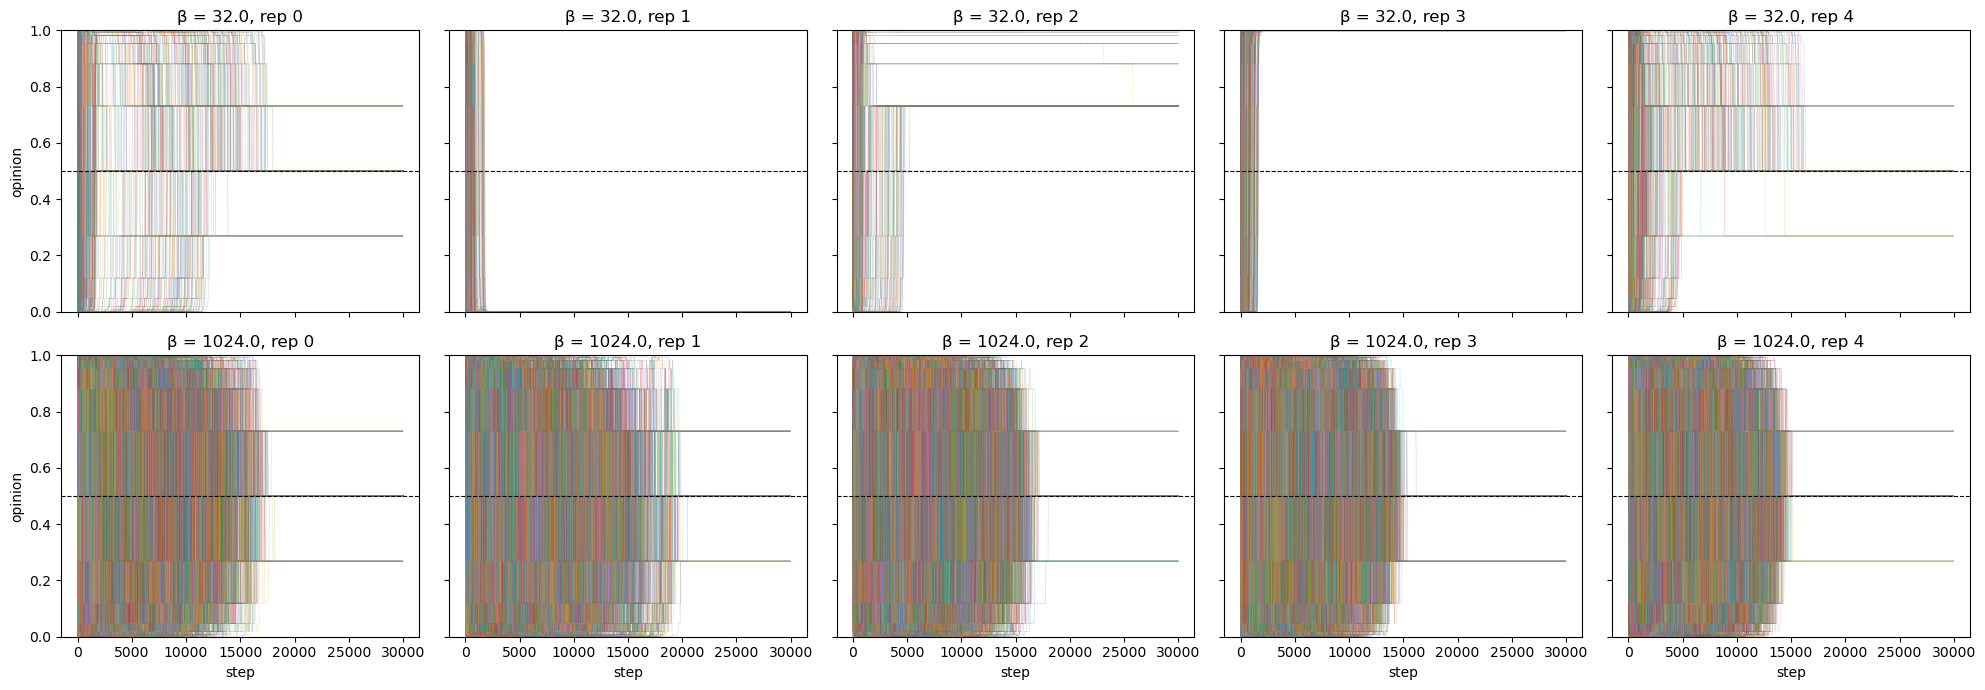

In [63]:
plot_trajectory_grid(sweep, [betas[2], betas[3]], n_reps=5, record_every=base.record_every)
fig.show()

C:\Users\nel_t\AppData\Local\Temp\ipykernel_27644\2562962998.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


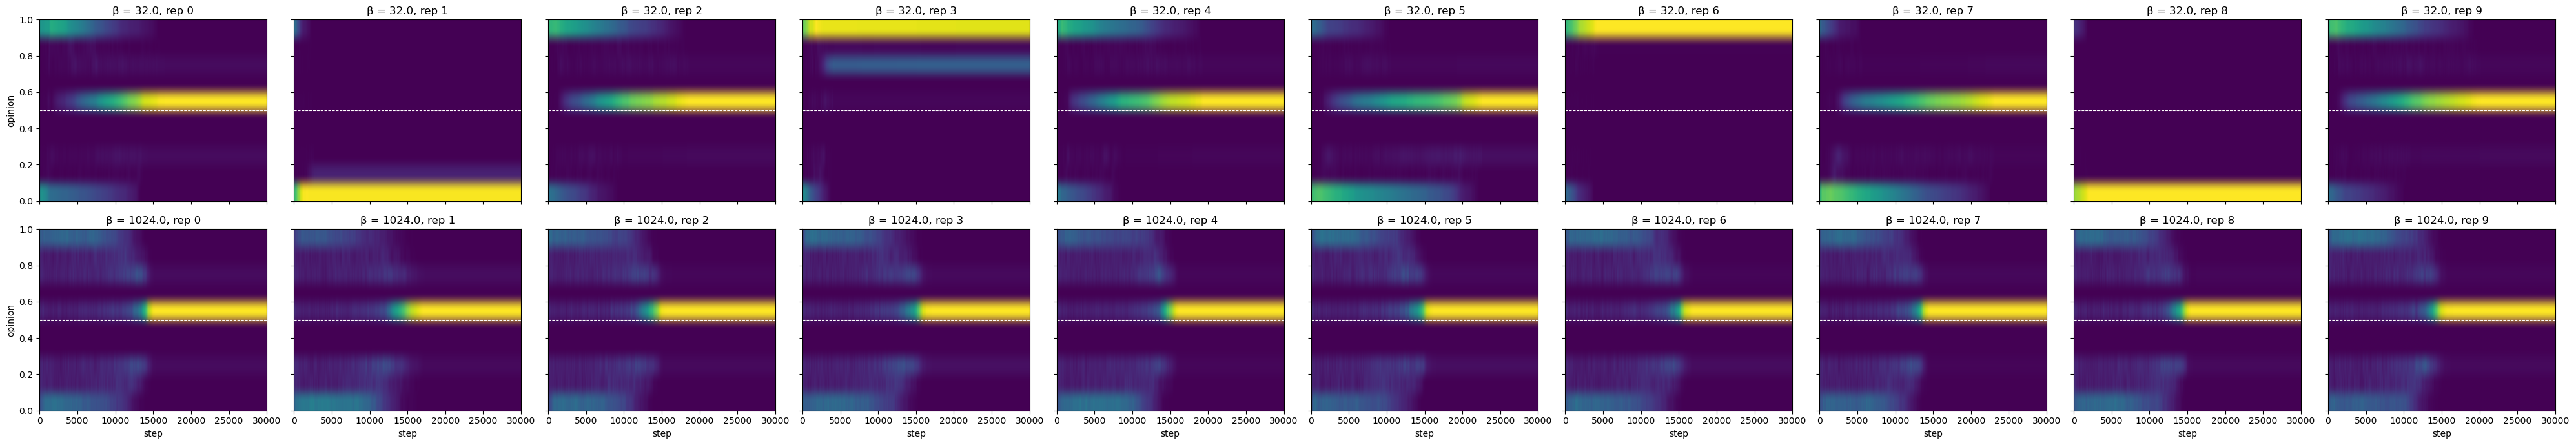

In [74]:
plot_trajectory_heatmap_grid(sweep, [betas[2], betas[3]], n_reps=10, record_every=base.record_every, n_bins = 10)
fig.show()

C:\Users\nel_t\AppData\Local\Temp\ipykernel_27644\2802670136.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


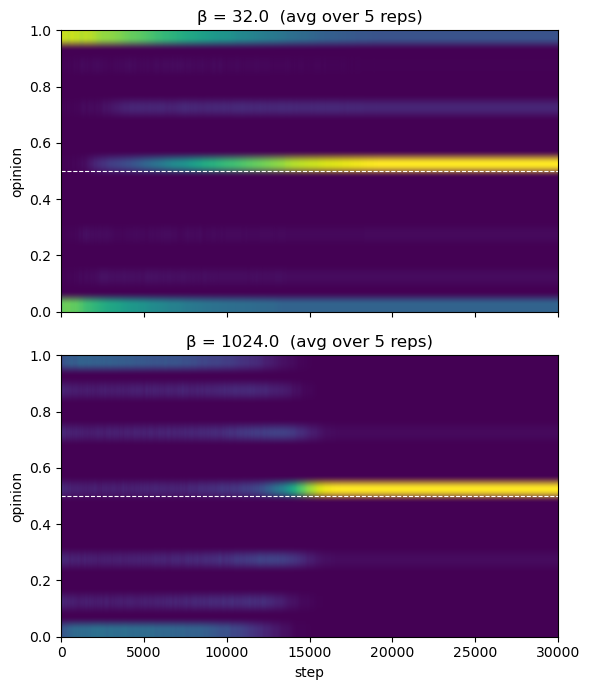

In [72]:
plot_trajectory_heatmap_avg(sweep, [betas[2], betas[3]], n_reps=5, record_every=base.record_every)
fig.show()

In [70]:
beta = 32
sweep[beta] = run_replicates_and_save_all_trajectories(replace(base, emission_temp=beta), n_reps=20, parallel=True)

In [71]:
beta = 1024
sweep[beta] = run_replicates_and_save_all_trajectories(replace(base, emission_temp=beta), n_reps=20, parallel=True)

In [60]:
len(sweep[32]['trajectories'][0][0])

500

In [58]:
fig,axs = plt.subplots(1,5,figsize=(15,3))
beta = 32
for i in range(5):
    traj = sweep[beta]['trajectories'][i]
    axs[i].plot(traj, label=f"β={beta}", color = 'black', alpha = 0.4)
    axs[i].set_title(f"Replicate {i+1}")
    axs[i].set_xlabel("Step")
    axs[i].set_ylabel("Opinion")
    axs[i].legend()

Error in callback <function flush_figures at 0x00000214EA893CE0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 